In [1]:
import os
import librosa # type: ignore
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import scipy.signal as signal
import scipy.signal as spy
from scipy.signal import firwin, freqz
import noisereduce as nr # type: ignore

/Users/panya/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def plotSpectrogram (data,sample_rate,title):
    # convert to spectrogram 
    spectrogram = librosa.feature.melspectrogram(y=data, sr=sample_rate)
    spectrogram = librosa.power_to_db(spectrogram, ref=np.max)

    plt.figure(figsize=(8,4))
    plt.title(title)
    librosa.display.specshow(spectrogram, x_axis='time', y_axis='hz',cmap='viridis')  #cmap = 'viridis', 'plasma', 'inferno', 'magma', 'cividis'
    plt.colorbar(format='%+2.0f dB')
    plt.xlabel('Time')
    plt.ylabel('Frequency')


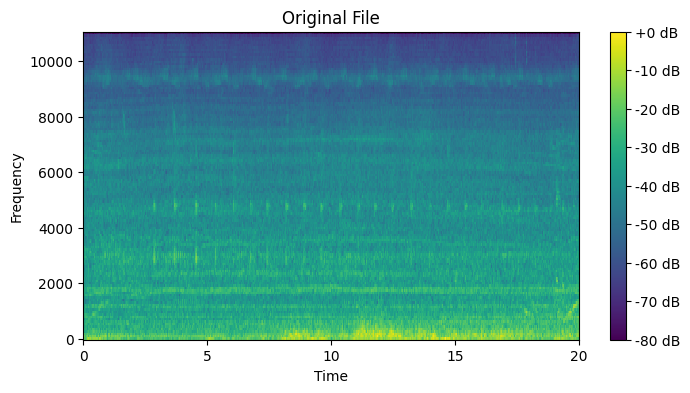

In [3]:
#Example to show spectrogram data 
audio_path = "./dataset/High20m_50m_#3.wav"
#audio_path = "/Users/panya/Project-ALL/DroneClassification/AcousticDroneDetection/dataset/No_Drone/เสียงธรรมชาติ(สายสั้น)-ex8.wav"
audio_original, sample_rate = librosa.load(audio_path, duration=20)  # Load audio and limit to 3 seconds

plotSpectrogram(audio_original, sample_rate,"Original File")

/var/folders/30/l0wngnb94zn7v2w3gg2pjbr80000gn/T/ipykernel_1977/2753311982.py:17: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(0.5*fs*w/np.pi, 20*np.log10(np.abs(h)), 'b')


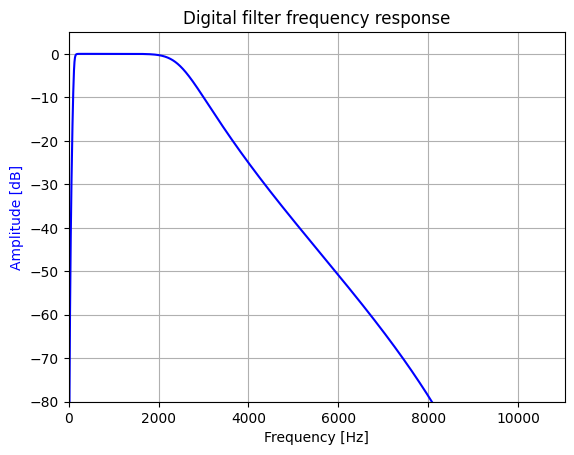

In [4]:
lowcut = 250.0   
highcut = 5000.0 
order=5
fs=sample_rate
    
nyquist = 1 * fs
low = lowcut / nyquist
high = highcut / nyquist
b, a = signal.butter(order, [low, high], btype='band')

# Compute the frequency response of the filter
w, h = freqz(b, a, worN=2000)

# Plot the frequency response
fig, ax1 = plt.subplots()
ax1.set_title('Digital filter frequency response')
ax1.plot(0.5*fs*w/np.pi, 20*np.log10(np.abs(h)), 'b')
ax1.set_ylabel('Amplitude [dB]', color='b')
ax1.set_xlabel('Frequency [Hz]')
ax1.set_ylim([-80, 5])
ax1.set_xlim([0, 0.5*fs])
ax1.grid()

plt.show()

In [7]:


def bandpass_filter(data, fs):
    
    nyquist = 1 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = signal.butter(order, [low, high], btype='band')
    y = signal.lfilter(b, a, data)
    
    return y

In [ ]:
# band pass filter 
#audio_BPF = butter_bandpass_filter(audio_normalize,lowcut,highcut,sample_rate,order=7)
audio_BPF = bandpass_filter(audio_original,sample_rate)

plotSpectrogram(audio_BPF, sample_rate,"Original File")

In [ ]:

# Noise reduce
Audio_Reduced_Noise = nr.reduce_noise(y=audio_BPF, sr=sample_rate,prop_decrease = 1)
plotSpectrogram(audio_BPF, sample_rate,"Original File")
